# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre: Kevin Rogelio Rodriguez Magaña

* **matrícula:A01840418

------------

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++

Entiendo por rotacion de personal, al constante despido , renuncia y contratacion de nuevos empleados. Haciendo que se tenga que capicitar y cargar con todos lo que esto incluye siendo una problematica para las empresas




++++++++ Termina la sección de agregar texto. +++++++++++

In [1]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [3]:
path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv.xls"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a)  Realiza los análisis descriptivos y/o gráficos que creas adecuados, para identificar 4 factores que se deben eliminar desde un inicio.**

**b) Con base a tu análisis anterior, indica cuáles son estas 4 variables y la justificación de por qué se pueden eliminar.**

**c) Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

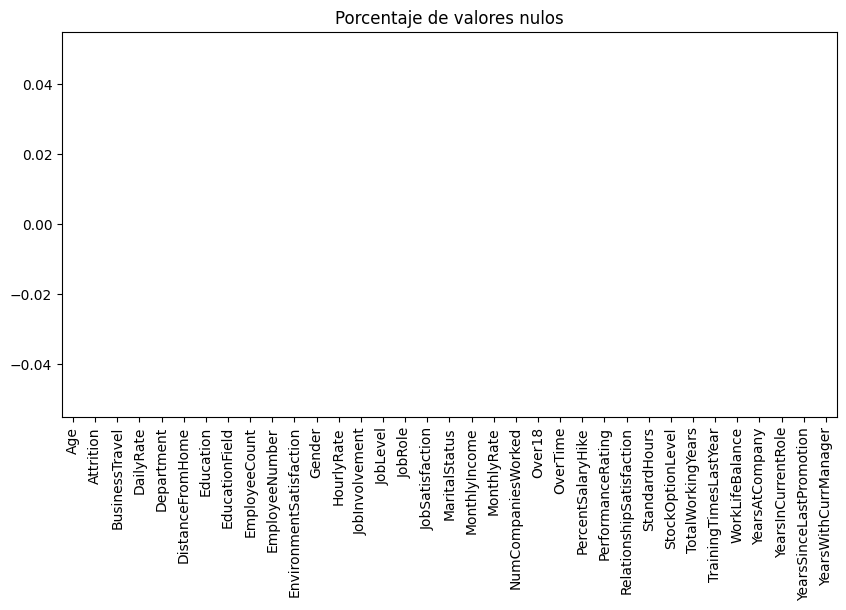

Age
Age
35    0.053061
34    0.052381
36    0.046939
31    0.046939
29    0.046259
Name: proportion, dtype: float64
-----
Attrition
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64
-----
BusinessTravel
BusinessTravel
Travel_Rarely        0.709524
Travel_Frequently    0.188435
Non-Travel           0.102041
Name: proportion, dtype: float64
-----
DailyRate
DailyRate
691     0.004082
1082    0.003401
329     0.003401
530     0.003401
408     0.003401
Name: proportion, dtype: float64
-----
Department
Department
Research & Development    0.653741
Sales                     0.303401
Human Resources           0.042857
Name: proportion, dtype: float64
-----
DistanceFromHome
DistanceFromHome
2     0.143537
1     0.141497
10    0.058503
9     0.057823
3     0.057143
Name: proportion, dtype: float64
-----
Education
Education
3    0.389116
4    0.270748
2    0.191837
1    0.115646
5    0.032653
Name: proportion, dtype: float64
-----
EducationField
EducationField
Life Scienc

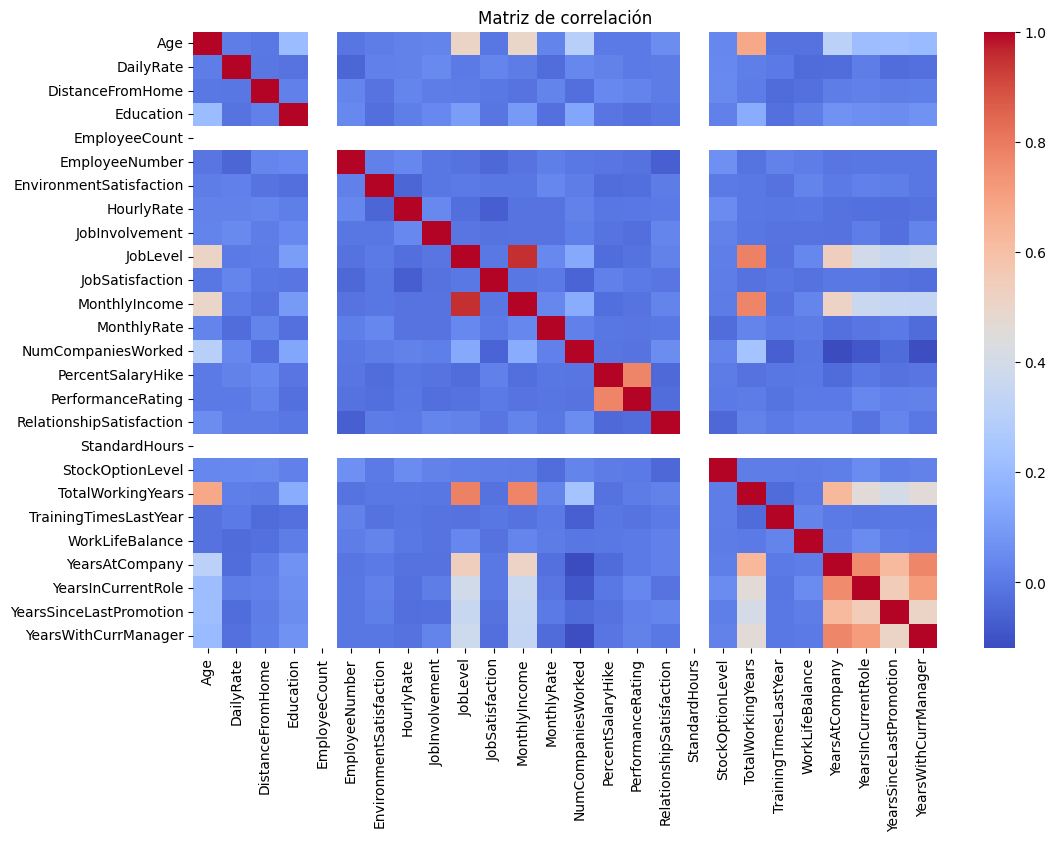

(1470, 31)
Tamaño del nuevo DataFrame: (1470, 31)


In [9]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# datos
df_original = data.copy()
df = df_original.copy()
print(df_original.info())

print(df_original.describe())

#nporcentaje de nulos

nulos = (df_original.isnull().sum()/len(df_original))*100

print(nulos.sort_values(ascending=False))

plt.figure(figsize=(10,5))

nulos.sort_values(ascending=False).plot(kind='bar')

plt.title("Porcentaje de valores nulos")

plt.show()

# 2. Variables constantes o casi constantes


for col in df_original.columns:

    print(col)

    print(df_original[col].value_counts(normalize=True).head())

    print("-----")


# 3. Correlaciones

corr = df_original.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr,cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()
#–----------------  C
df = df_original.drop(
    columns=['EmployeeCount','StandardHours','EmployeeNumber','MonthlyRate'])

print(df.shape)
# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)


"""
1. EmployeeCount
     Aparece completamente en blanco en la matriz de correlación y esto suele indicar que tiene un único valor para todos los registros
2. StandardHours
     En este dataset de empleados suele tener un valor fijo
3. EmployeeNumber
     Es un id de empleado.
4. MonthlyRate
     Presenta correlaciones muy cercanas a 0 con casi todas las variables.

*/"""

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes.**

#### **Realiza los análisis que creas adecuados para clasificar cada una de nuestras variables según su tipo.**

#### **Debes analizar todas las variables de entrada y también la de salida.**


++++++++ Inicia la sección de agregar texto: ++++++++++++

**a)   Variables numéricas:**

Número de variables: 14

Nombre de las variables:

* Age
* DailyRate
* DistanceFromHome
* HourlyRate
* MonthlyIncome
* NumCompaniesWorked
* PercentSalaryHike
* TotalWorkingYears
* TrainingTimesLastYear
* YearsAtCompany
* YearsInCurrentRole
* YearsSinceLastPromotion
* YearsWithCurrManager
* Attrition

**b)   Variables ordinales:**

Número de variables: 8

Nombre de las variables:

Las 7 variables indicadas por Kaggle:

* Education
* EnvironmentSatisfaction
* JobInvolvement
* JobSatisfaction
* PerformanceRating
* RelationshipSatisfaction
* WorkLifeBalance

##### NOTA: Considera aquí las 7 variables que se indican en la página de Kaggle e incluye también las variables "Level".


**c)   Variables binarias:**

Número de variables: 5

Nombre de las variables:

* Attrition
* OverTime
* Gender
* Over18
* RemoteWork


**d)   Variables nominales:**

Número de variables: 8

Nombre de las variables:

* BusinessTravel
* Department
* EducationField
* JobRole
* MaritalStatus
* StockOptionLevel
* Gender
* OverTime



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

#### **Como hemos comentado previamente, la forma en que se particiona el conjunto de datos es un aspecto fundamental dentro del área de aprendizaje automático. Ahora que ya también conoces la técnica de Validación Cruzada, explica cómo puede utilizarse cada una de las particiones iniciales indicadas y cuáles son los pros y contras de utilizar cada una de ellas. Se desea comparar la partición inicial de Train+Validation, en contraste con la partición Train+Validation+Test.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

**a) Partición Train+Validation:**
Pros:

* Permite entrenar el modelo utilizando una mayor cantidad de datos disponibles.
* Al aplicar Validación Cruzada dentro del conjunto de entrenamiento, los datos se dividen varias veces para entrenar y validar, generando una evaluación más robusta.
* Reduce la dependencia de una sola división de datos, disminuyendo el sesgo causado por una selección específica de muestras.
* Es especialmente útil cuando el conjunto de datos es pequeño, ya que aprovecha mejor la información disponible.

Contras:

* No existe un conjunto independiente de prueba final para evaluar el desempeño real del modelo.
* Puede producir estimaciones optimistas del rendimiento, ya que los datos se reutilizan múltiples veces durante la validación cruzada.
* Existe mayor riesgo de sobreajuste durante la selección y ajuste de hiperparámetros.
**b) Partición Train+Validation+Test:**


Pros:

* Mantiene un conjunto de prueba (Test) completamente separado que no participa en el entrenamiento ni en la selección de hiperparámetros.
* Permite obtener una evaluación más realista de la capacidad de generalización del modelo.
* La validación cruzada puede aplicarse únicamente sobre Train+Validation para optimizar el modelo y después medir el desempeño final sobre Test.
* Reduce el riesgo de sesgo en la evaluación final.

Contras:

* Disminuye la cantidad de datos disponibles para entrenamiento debido a la separación del conjunto Test.
* Si el dataset es pequeño, el modelo puede entrenarse con menos información y afectar el desempeño.
* Requiere más tiempo computacional al combinar separación de datos y validación cruzada.






  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [11]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [14]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


from sklearn.preprocessing import LabelEncoder
import pandas as pd
le = LabelEncoder()

le.fit(ytrain)

ytrainT = le.transform(ytrain)
yvalT   = le.transform(yval)
ytestT  = le.transform(ytest)


print(le.classes_)


# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

# Convert ytrainT to a pandas Series and map back to original labels for display
print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', pd.Series(le.inverse_transform(ytrainT)).value_counts(normalize=True))

['No' 'Yes']
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 No     0.838678
Yes    0.161322
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was 

#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la proporción de datos de cada clase obtenida, indica si podemos considerar que tenemos un problema de datos desbalanceados.**

**e) Con base a esta información, ¿cuál será el umbral del modelo base (baseline) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**




++++++++ Inicia la sección de agregar texto: ++++++++++++

## **SOLUCIÓN PARA EL PROFESOR:**

b)   De acuerdo con la documentación oficial de Scikit-learn, LabelEncoder está diseñado para transformar variables objetivo o variables de salida (target, y) y no las variables de entrada (X). Su objetivo es convertir etiquetas categóricas en valores numéricos entre 0 y n_classes − 1.   

c) Después de aplicar LabelEncoder:

* 0 (No): el empleado permanece en la empresa, es decir, no presenta abandono o rotación laboral.
* 1 (Yes): el empleado abandona la empresa, es decir, deja la organización.

La variable Attrition representa entonces el evento de rotación de personal.

d) En el dataset IBM HR Attrition la distribución suele ser aproximadamente:

* No (0): 84%
* Yes (1): 16%

Existe una diferencia considerable entre ambas clases, por lo que sí puede considerarse un problema de datos desbalanceados. La clase mayoritaria domina el conjunto de datos y un modelo podría sesgarse hacia predecir la clase más frecuente.

e) Entonces un clasificador trivial que siempre prediga  no obtendría alrededor de:

Baseline de 84%

Por lo tanto, cualquier modelo desarrollado deberá superar aproximadamente ese porcentaje para demostrar que aprende patrones útiles y evitar considerarse un modelo subentrenado.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Incluye algunos comentarios sobre los resultados y gráficos obtenidos.**


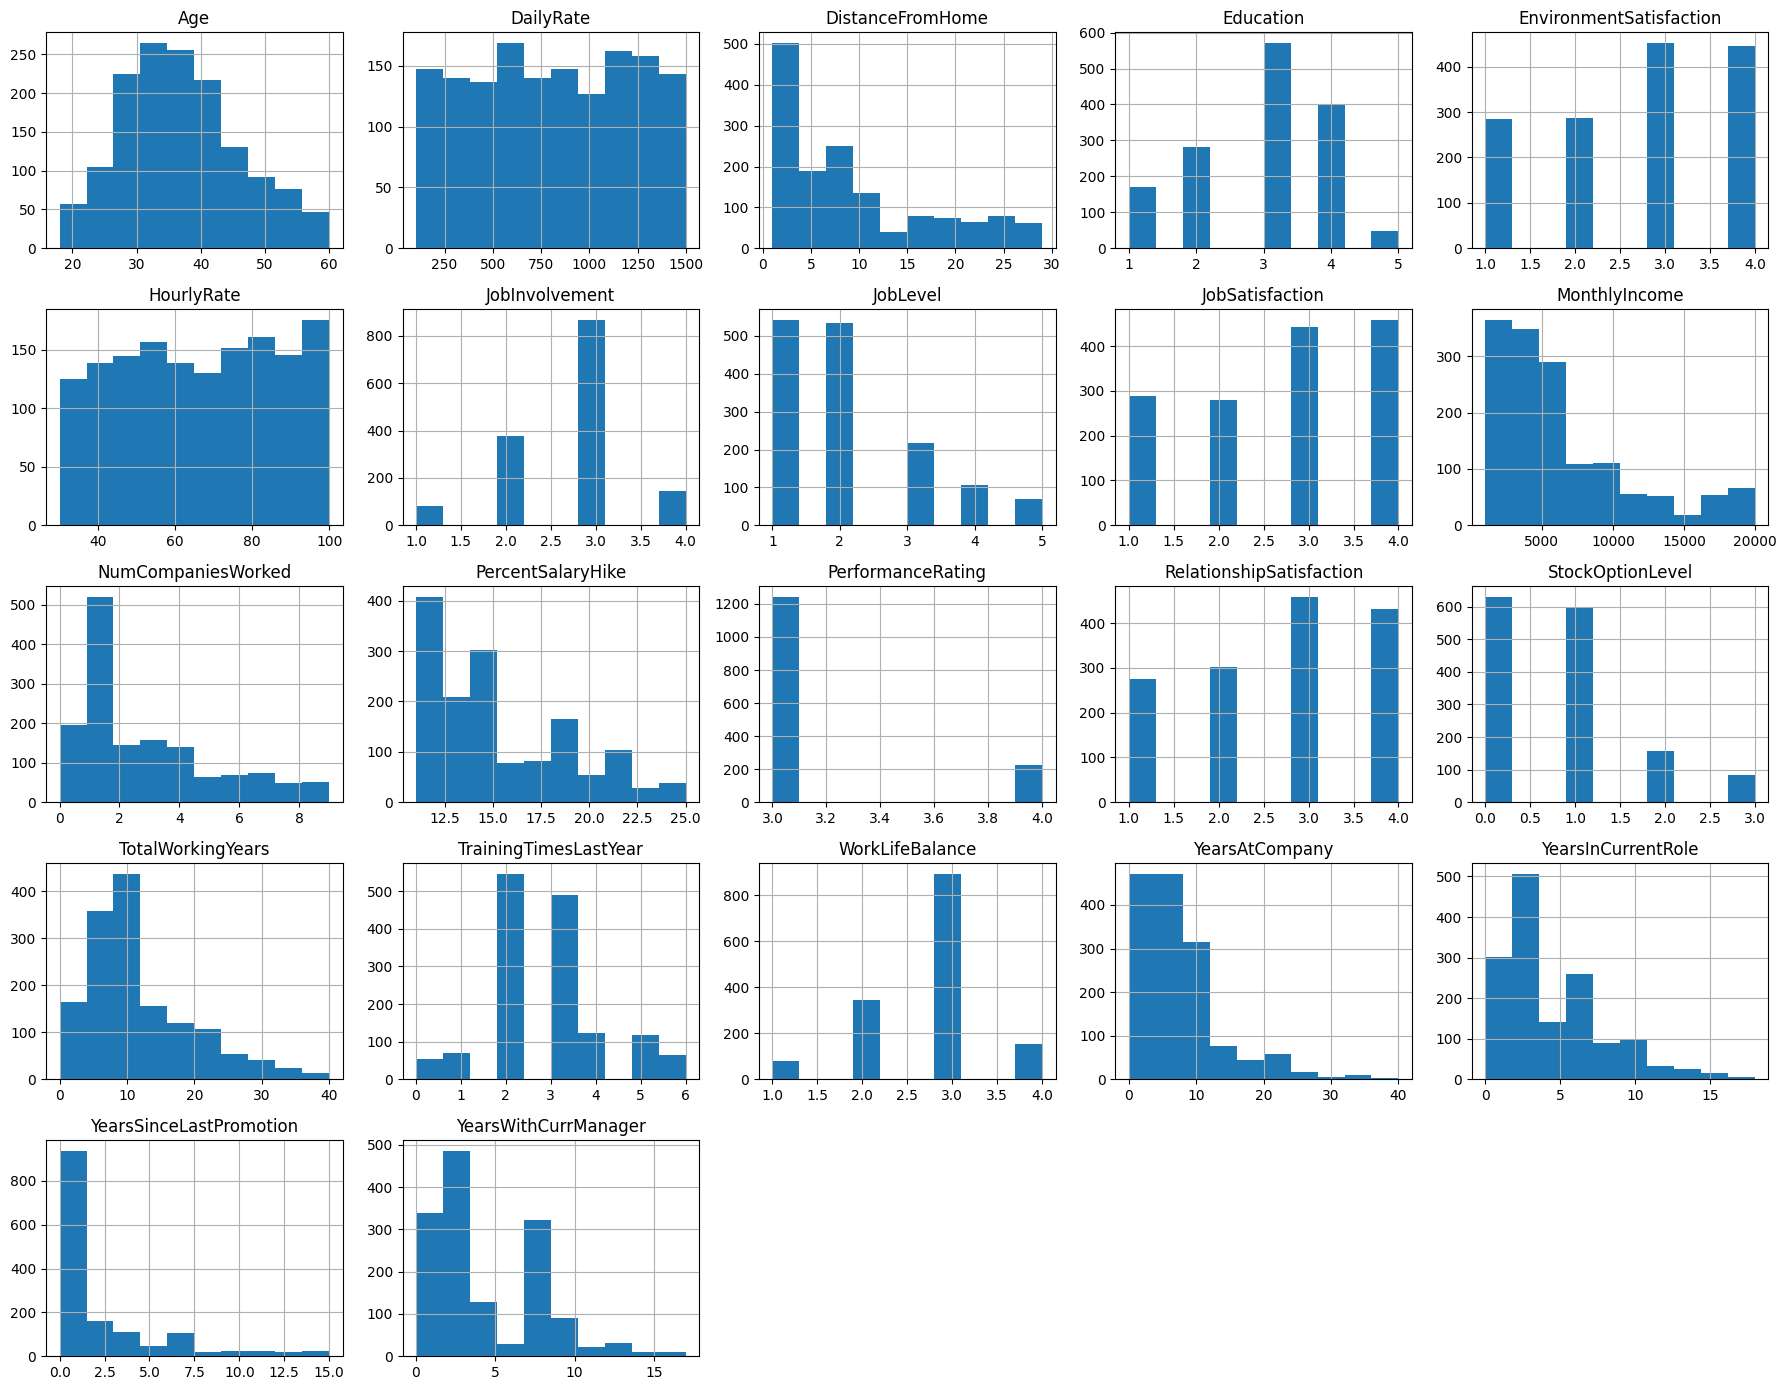

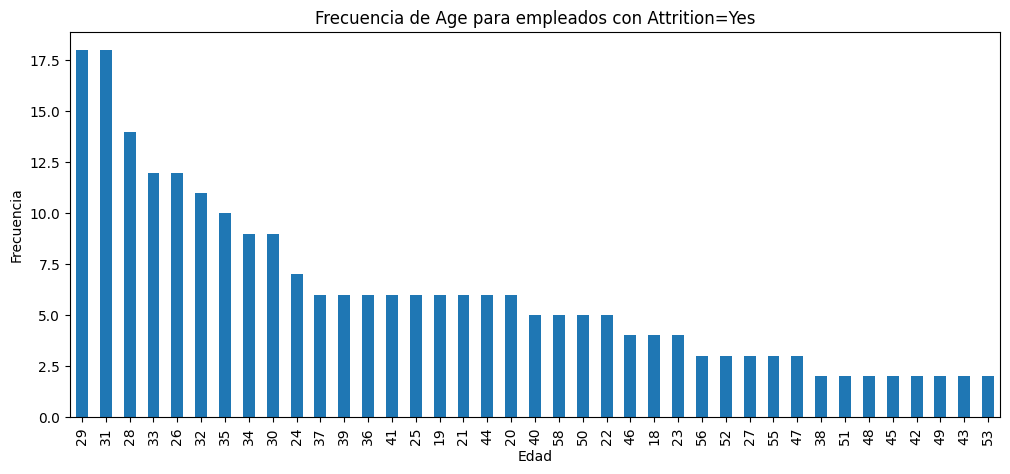

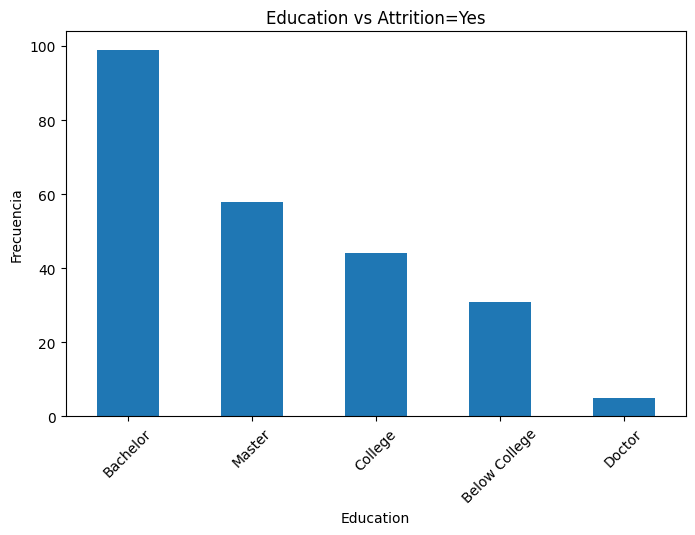

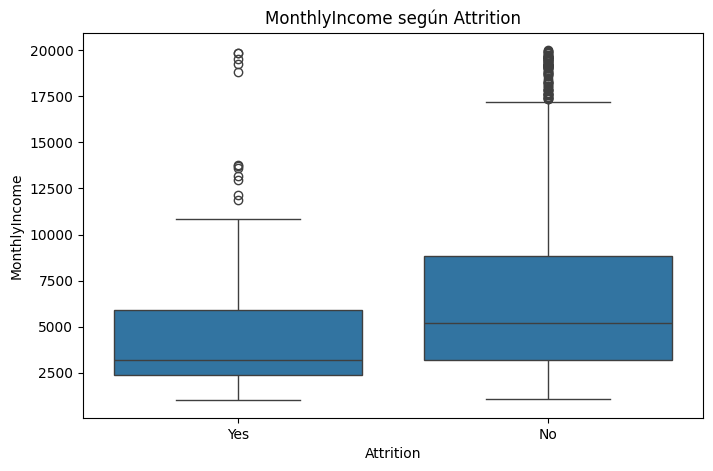

In [17]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

import matplotlib.pyplot as plt

df.hist(figsize=(18,14))
plt.tight_layout()
plt.show()


# b) Gráfico age-attrition[yes]

attrition_yes = df[df['Attrition']=="Yes"]

age_counts = attrition_yes['Age']\
                .value_counts()\
                .sort_values(ascending=False)

plt.figure(figsize=(12,5))
age_counts.plot(kind='bar')

plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Frecuencia de Age para empleados con Attrition=Yes")

plt.show()

# c) Gráfico education-attrition[yes]

education_labels = {
    1:'Below College',
    2:'College',
    3:'Bachelor',
    4:'Master',
    5:'Doctor'
}

edu_attrition = df[df['Attrition']=="Yes"]['Education']
edu_attrition = edu_attrition.replace(
                    education_labels
                )
edu_counts = edu_attrition.value_counts()
edu_counts = edu_counts.sort_values(
                    ascending=False)

plt.figure(figsize=(8,5))
edu_counts.plot(kind='bar')
plt.xlabel("Education")
plt.ylabel("Frecuencia")
plt.title("Education vs Attrition=Yes")
plt.xticks(rotation=45)
plt.show()

# d) [gráfico opcional]

import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.title(
    'MonthlyIncome según Attrition'
)
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) Comentarios sobre los incisos anteriores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

nos ayuda a identificar si existen diferencias salariales importantes entre empleados que permanecen y quienes abandonan la organización. También permite detectar valores atípicos y dispersión.



++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo.**



In [19]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

from sklearn.preprocessing import StandardScaler # Added this import

# NUMÉRICAS:

numericas_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numericas_pipeline_nombres = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# ORDINALES:

catOrd_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

catOrd_pipeline_nombres = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'JobLevel'

]

# BINARIAS:

catBin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

catBin_pipeline_nombres = [
    'Gender',
    'OverTime',
    'Over18'
]

# NOMINALES:

catNom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first' ))

])

catNom_pipeline_nombres = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'

]

columnasTransformer = ColumnTransformer([
    ('num', numericas_pipeline,
     numericas_pipeline_nombres),
    ('ord', catOrd_pipeline,
     catOrd_pipeline_nombres),
    ('bin', catBin_pipeline,
     catBin_pipeline_nombres),
    ('nom', catNom_pipeline,
     catNom_pipeline_nombres)
])

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [22]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([pd.Series(ytrainT), pd.Series(yvalT)], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249,)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados.**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados. En esta y próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera el problema y obtener mejores desempeños.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold", puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.782 (0.020)
>> LASSO 0.786 (0.025)
>> RIDGE 0.787 (0.025)
>> EN 0.786 (0.025)
>> kNN 0.848 (0.006)


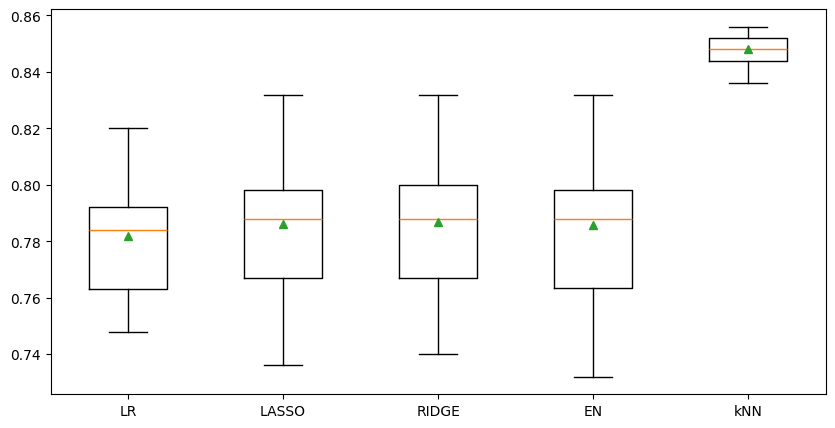

In [25]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás cambiarlo

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

def mis_modelos():

  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(
      LogisticRegression(
          penalty=None,
          solver='lbfgs',
          max_iter=5000,
          class_weight='balanced',
          random_state=1
      )
  )
  nombres.append('LR')


  # Lasso:
  modelos.append(
      LogisticRegression(
          penalty='l1',
          solver='saga',
          C=1.0,
          max_iter=5000,
          class_weight='balanced',
          random_state=1
      )
  )
  nombres.append('LASSO')


  # Ridge:
  modelos.append(
      LogisticRegression(
          penalty='l2',
          solver='lbfgs',
          C=0.5,
          max_iter=5000,
          class_weight='balanced',
          random_state=1
      )
  )
  nombres.append('RIDGE')


  # ElasticNet:
  modelos.append(
      LogisticRegression(
          penalty='elasticnet',
          solver='saga',
          l1_ratio=0.5,
          C=1.0,
          max_iter=5000,
          class_weight='balanced',
          random_state=1
      )
  )
  nombres.append('EN')


  # KNN:
  modelos.append(
      KNeighborsClassifier(
          n_neighbors=9,
          weights='distance',
          metric='minkowski',
          p=2
      )
  )

  nombres.append('kNN')

  return modelos, nombres


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay varias maneras de entrenarlo pero por el momento utilicemos la siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados.


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo y por qué. ¿Alguno quedó subentrenado?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Los modelos LR, LASSO, RIDGE y Elastic Net obtuvieron resultados muy similares, con exactitudes entre 78 y 79. En contraste, kNN alcanzó el mejor desempeño con 84.8 y 0.006, además de mostrar menor variabilidad entre particiones.

Se considera que kNN es el mejor modelo, ya que obtuvo la mayor exactitud y presentó resultados más estables en el diagrama de cajas.

Tomando como referencia el baseline 84%, los modelos de regresión logística quedaron por debajo de este valor, por lo que pueden considerarse subentrenados. El modelo kNN sí logró superar el baseline.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [26]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++




from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('ct', columnasTransformer),
    ('m', KNeighborsClassifier())
])

param_grid = {
    'm__n_neighbors':[3,5,7,9,11,13,15],
    'm__weights':['uniform','distance'],
    'm__metric':['minkowski'],
    'm__p':[1,2]
}

cv2 = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=7
)

resultado_malla = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    scoring='accuracy',
                    cv=cv2,
                    return_train_score=True,
                    n_jobs=-1
                  )

resultado_malla.fit(Xtv, np.ravel(ytv))





# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.852680 usando los hiperparámetros {'m__metric': 'minkowski', 'm__n_neighbors': 11, 'm__p': 1, 'm__weights': 'uniform'}
Promedios Train mean(std): 93.15% (0.1834%)
Promedios Val mean(std): 84.72% (0.7674%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [28]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# Predicciones con el mejor modelo
y_pred = resultado_malla.predict(Xtest)

print(classification_report(
        ytestT,
        y_pred,
        target_names=['No','Yes']
))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

              precision    recall  f1-score   support

          No       0.84      1.00      0.91       185
         Yes       0.00      0.00      0.00        36

    accuracy                           0.84       221
   macro avg       0.42      0.50      0.46       221
weighted avg       0.70      0.84      0.76       221



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

from sklearn.metrics import confusion_matrix # Added this import

# Predicciones
y_pred = resultado_malla.predict(Xtest)

# Matriz de confusión
mc = confusion_matrix(ytestT, y_pred)

print(mc)


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

[[185   0]
 [ 36   0]]


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

    VP: Empleados que realmente abandonaron la empresa (Attrition=Yes) y el modelo predijo correctamente que abandonarían.
* VN: Empleados que permanecieron en la empresa (Attrition=No) y el modelo predijo correctamente que permanecerían.
* FP: Empleados que permanecieron en la empresa, pero el modelo predijo incorrectamente que abandonarían.
* FN: Empleados que realmente abandonaron la empresa, pero el modelo predijo incorrectamente que permanecerían. Este caso es especialmente importante porque implica no detectar empleados con riesgo de abandonar la compañía.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

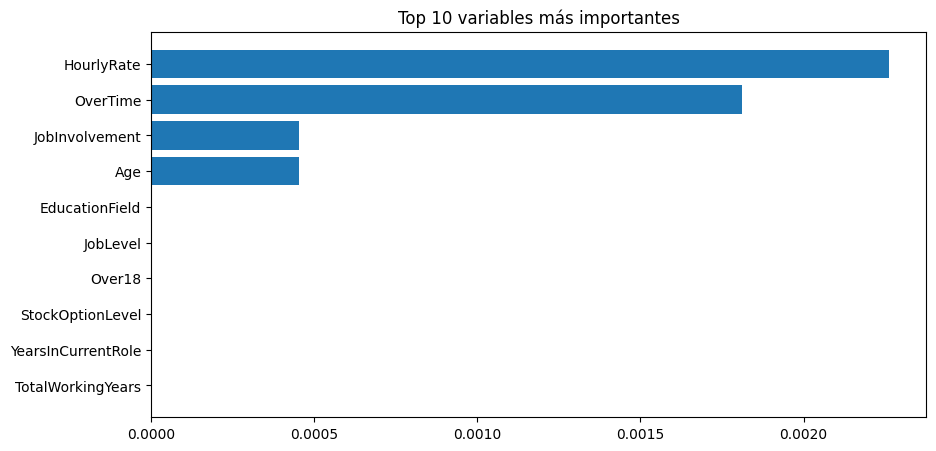

              Variable   Importancia
9           HourlyRate  2.262443e-03
18            OverTime  1.809955e-03
10      JobInvolvement  4.524887e-04
0                  Age  4.524887e-04
6       EducationField  1.110223e-17
11            JobLevel  0.000000e+00
17              Over18  0.000000e+00
22    StockOptionLevel  0.000000e+00
27  YearsInCurrentRole  0.000000e+00
23   TotalWorkingYears  0.000000e+00


In [34]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


from sklearn.inspection import permutation_importance

import pandas as pd

import matplotlib.pyplot as plt

# Importancia de variables

imp = permutation_importance(

        resultado_malla.best_estimator_,

        Xtest,

        ytestT,

        n_repeats=10,

        random_state=1,

        scoring='accuracy'

)

# nombres de variables transformadas
# The permutation_importance calculates importance for the original features in Xtest.
# So, we should use the original column names for alignment.
df_imp = pd.DataFrame({

    'Variable': Xtest.columns, # Use original column names for variables

    'Importancia': imp.importances_mean

})

df_imp = df_imp.sort_values(

            by='Importancia',

            ascending=False

         ).head(10)

# gráfico

plt.figure(figsize=(10,5))

plt.barh(

    df_imp['Variable'],

    df_imp['Importancia']

)

plt.gca().invert_yaxis()

plt.title('Top 10 variables más importantes')

plt.show()

print(df_imp)


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

El análisis de importancia permitió identificar qué características influyen más en la decisión de que un empleado permanezca o abandone la empresa. Variables como la antigüedad, salario, experiencia o nivel del puesto parecen tener una mayor relación con la rotación de personal.

Las variables más importantes ayudan a entender mejor qué factores pueden estar asociados con la salida de empleados. Esta información puede ser útil para que la empresa identifique posibles causas y tome decisiones para mejorar la permanencia del personal.


#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quién de los colaboradores una empresa estará abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**


Si el modelo identifica empleados con alta probabilidad de abandonar la empresa, la información debe utilizarse como una herramienta de apoyo y no para tomar decisiones automáticas. El objetivo debería ser mejorar el ambiente laboral, identificar posibles problemas y ofrecer acciones como capacitación, seguimiento o mejoras en condiciones de trabajo. También es importante proteger la privacidad del colaborador y evitar generar etiquetas o discriminación.

* **b) En tu opinión y en el contexto del problema ¿qué consecuencias crees que tendría en la práctica el utilizar un modelo que tiene un alto valor de exhaustividad (recall), pero con baja precisión (precision), en el departamento de Recursos Humanos (RRHH)?**


Un modelo con alto recall detectaría a la mayoría de los empleados que podrían abandonar la empresa, pero una baja precision generaría muchos falsos positivos. En la práctica, RRHH podría invertir tiempo y recursos en empleados que realmente no tenían intención de irse. Aunque esto ayuda a no dejar pasar casos importantes, también puede provocar decisiones innecesarias o desgaste de recursos.

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, podemos suponer que se lo vas a comunicar a los directivos de tu empresa o al personal de RRHH.**

Los resultados se comunicarían de forma sencilla, explicando que el modelo ayuda a identificar patrones relacionados con la rotación de empleados. En lugar de hablar de algoritmos o métricas complejas, se presentaría como una herramienta que permite detectar factores asociados con la salida del personal para apoyar la toma de decisiones y mejorar estrategias de retención.

* **d) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


Esta actividad mepermitió comprender todo el proceso de aprendizaje automático: análisis de datos, preparación, transformación, entrenamiento y evaluación de modelos. También mostró la importancia de seleccionar correctamente las variables y ajustar hiperparámetros para obtener mejores resultados. Además, se observó que los modelos no solo deben evaluarse por su desempeño, sino también considerar el contexto, la interpretación y las implicaciones éticas de su uso.


#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de la Semana 3** <<